# WorldSim DGX Spark QLoRA Baseline Training

This notebook is the hardened DGX baseline path. It uses the shared baseline trainer and fails early if the runtime cannot satisfy true CUDA QLoRA.


## 1. Repo Root Guard


In [1]:
from pathlib import Path
import sys

cwd = Path.cwd()
repo_marker = cwd / 'training/run_qlora_train.py'
notebook_marker = cwd / 'notebooks/dgx_spark_qlora_train.ipynb'
assert repo_marker.exists() and notebook_marker.exists(), (
    f'Run this notebook from the WorldSim repo root. cwd={cwd} repo_marker={repo_marker}'
)
{
    'python_executable': sys.executable,
    'cwd': str(cwd),
    'repo_marker': str(repo_marker),
    'repo_marker_exists': repo_marker.exists(),
}


{'python_executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3',
 'cwd': '/home/hyunlord/github/worldsim-training',
 'repo_marker': '/home/hyunlord/github/worldsim-training/training/run_qlora_train.py',
 'repo_marker_exists': True}

## 2. Environment Visibility


In [2]:
from training.lib.qlora_smoke import get_environment_summary

environment = get_environment_summary()
torch_info = environment.get('torch', {})
training_stack = {
    name: environment.get(name, {'available': False, 'version': None})
    for name in ('transformers', 'peft', 'trl', 'datasets', 'accelerate', 'bitsandbytes')
}
env_visibility = {
    'python_executable': environment.get('python', {}).get('executable'),
    'cwd': environment.get('cwd'),
    'torch_version': torch_info.get('version'),
    'torch_cuda_version': torch_info.get('cuda_version'),
    'torch_cuda_available': torch_info.get('cuda_available'),
    'gpu_count': torch_info.get('cuda_device_count', 0),
    'gpu_names': torch_info.get('cuda_device_names', []),
    'training_stack': training_stack,
    'environment': environment,
}
env_visibility


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'python_executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3',
 'cwd': '/home/hyunlord/github/worldsim-training',
 'torch_version': '2.12.0.dev20260225+cu130',
 'torch_cuda_version': '13.0',
 'torch_cuda_available': True,
 'gpu_count': 1,
 'gpu_names': ['NVIDIA GB10'],
 'training_stack': {'transformers': {'available': True, 'version': '5.2.0'},
  'peft': {'available': True, 'version': '0.18.1'},
  'trl': {'available': False,
   'error': "ModuleNotFoundError: No module named 'trl'"},
  'datasets': {'available': True, 'version': '4.7.0'},
  'accelerate': {'available': True, 'version': '1.12.0'},
  'bitsandbytes': {'available': True, 'version': '0.49.2'}},
 'environment': {'python': {'version': '3.12.3',
   'executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3'},
  'platform': {'system': 'Linux',
   'release': '6.14.0-1015-nvidia',
   'machine': 'aarch64'},
  'cwd': '/home/hyunlord/github/worldsim-training',
  'torch': {'available': True,
   'version': '

## 3. Strict True-QLoRA Preflight


In [3]:
from training.lib.qlora_smoke import get_true_qlora_preflight

preflight = get_true_qlora_preflight()
preflight
assert preflight['ok'], preflight['blocker_reason']


## 4. Baseline Config


In [4]:
from datetime import UTC, datetime

from training.lib.qlora_smoke import BASELINE_MODEL_NAME, resolve_baseline_notebook_config

RUN_ID = datetime.now(UTC).strftime('run-%Y%m%dT%H%M%SZ')
OUTPUT_DIR_OVERRIDE = None
CONFIG = resolve_baseline_notebook_config(
    RUN_ID,
    output_dir_override=OUTPUT_DIR_OVERRIDE,
    overrides={
        'model_name': BASELINE_MODEL_NAME,
        'dry_run': False,
        'require_qlora': True,
        'max_train_samples': 0,
        'max_eval_samples': 0,
        'max_steps': 200,
        'gradient_accumulation_steps': 8,
        'learning_rate': 1e-4,
        'logging_steps': 5,
        'eval_steps': 25,
        'save_steps': 25,
        'save_total_limit': 2,
    },
)
CONFIG


{'run_mode': 'baseline',
 'run_id': 'run-20260313T020326Z',
 'dry_run': False,
 'model_name': 'Qwen/Qwen3.5-0.8B-Base',
 'dataset': 'worldsim-v31-mix-v1',
 'train_file': PosixPath('data/training/worldsim-v31-mix-v1/train_converted.jsonl'),
 'dev_file': PosixPath('data/training/worldsim-v31-mix-v1/dev_converted.jsonl'),
 'max_steps': 200,
 'max_train_samples': 0,
 'max_eval_samples': 0,
 'per_device_train_batch_size': 1,
 'per_device_eval_batch_size': 1,
 'gradient_accumulation_steps': 8,
 'learning_rate': 0.0001,
 'logging_steps': 5,
 'eval_steps': 25,
 'save_steps': 25,
 'save_total_limit': 2,
 'require_qlora': True,
 'seed': 42,
 'output_dir': PosixPath('outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z')}

## 5. Dataset Preview


In [5]:
from scripts.common import read_jsonl

train_preview_rows = read_jsonl(CONFIG['train_file'])[:3]
dataset_preview = [
    {
        'task': row.get('task'),
        'system': row['messages'][0]['content'],
        'user': row['messages'][1]['content'],
        'assistant': row['messages'][-1]['content'],
    }
    for row in train_preview_rows
]
dataset_preview


[{'task': 'A',
  'system': '너는 WorldSim 서사 도우미다. [TEMP], [STRESS], [WORLD]와 지정된 register를 반영해 JSON으로만 답하라. `*_ko` 필드는 순우리말로, `*_en` 필드는 자연스러운 영어로 쓰고, 길이와 문장 수를 정확히 지켜라.',
  'user': '[과제] 아래 인물의 기질과 성격을 이중언어 JSON으로만 묘사하라.\n\n[TEMP]\nNS=0.8 HA=0.2 RD=0.5 P=0.7 type=choleric\n\n[기질 이름]\n담즙질\n\n[기질 키워드]\n당당함, 충동적, 결단력, 지배적\n\n[성격 이름]\n신중한원로\n\n[성격 설명]\n위험을 경계하고 규율을 중시하는 어른\n\n[성격 키워드]\n겁많음, 꼼꼼함, 조용함, 규율중시\n\n[STRESS]\n0.1\n\n[WORLD]\ndefault\n\n[WORLD_DESC]\n석기시대, 지상자원 정상, 일반 생태계\n\n[WORLD_VOCAB]\n\n\n[어투]\n해라체로 써라. 문장을 -다, -는다, -았다, -었다 로 끝내라.\n\n[어투 코드]\nhaera\n\n[지배 기질축 선택지]\nnovelty_seeking, harm_avoidance, reward_dependence, persistence\n\n[출력 형식]\n{{"text_ko":"순우리말 1문장","text_en":"English 1 sentence","register":"haera","dominant_trait":"TCI 4축 중 하나","temperament_expressed":"choleric"}}\n\n[규칙]\n- text_ko는 순우리말 1문장 20~40글자로 써라\n- text_en은 같은 뜻의 자연스러운 영어 1문장으로 써라\n- register는 반드시 "haera"로 고정하라\n- dominant_trait는 위 기질에서 가장 두드러진 TCI 축 하나를 영어 소문자로 고르라\n- temperament_expressed는 반드시 "choler

## 6. Trainer Invocation


In [6]:
import time

from training.lib.qlora_smoke import SmokeRunConfig, run_baseline_or_raise

cfg = SmokeRunConfig(
    run_mode='baseline',
    model_name=CONFIG['model_name'],
    train_file=CONFIG['train_file'],
    dev_file=CONFIG['dev_file'],
    output_dir=CONFIG['output_dir'],
    max_steps=CONFIG['max_steps'],
    max_train_samples=CONFIG['max_train_samples'],
    max_eval_samples=CONFIG['max_eval_samples'],
    per_device_train_batch_size=CONFIG['per_device_train_batch_size'],
    per_device_eval_batch_size=CONFIG['per_device_eval_batch_size'],
    gradient_accumulation_steps=CONFIG['gradient_accumulation_steps'],
    learning_rate=CONFIG['learning_rate'],
    logging_steps=CONFIG['logging_steps'],
    eval_steps=CONFIG['eval_steps'],
    save_steps=CONFIG['save_steps'],
    save_total_limit=CONFIG['save_total_limit'],
    require_qlora=CONFIG['require_qlora'],
    seed=CONFIG['seed'],
    dry_run=CONFIG['dry_run'],
)

started_at = time.perf_counter()
result = run_baseline_or_raise(cfg)
elapsed_seconds = round(time.perf_counter() - started_at, 2)
{'elapsed_seconds': elapsed_seconds, 'result': result.to_dict()}


The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights:   2%|▏         | 6/320 [00:02<06:52,  1.31s/it, Materializing param=model.layers.0.linear_attn.in_proj_a.weight]/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 320/320 [00:07<00:00, 42.58it/s, Materializing param=model.norm.weight]                               
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's 

Step,Training Loss,Validation Loss
25,0.528937,0.443696
50,0.192688,0.149073
75,0.071382,0.086098
100,0.083034,0.065794
125,0.054638,0.055730
150,0.049007,0.050920
175,0.060329,0.047717
200,0.048222,0.046394


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1258: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1258: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between

[outlines] Constrained decoding ENABLED (model wrapped successfully)


/home/hyunlord/github/diffusion-study/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'elapsed_seconds': 1408.77,
 'result': {'success': True,
  'status': 'ok',
  'used_true_qlora': True,
  'runtime': {'device': 'cuda',
   'use_qlora': True,
   'fallback_reason': None,
   'torch_dtype': 'bfloat16'},
  'environment': {'python': {'version': '3.12.3',
    'executable': '/home/hyunlord/github/diffusion-study/.venv/bin/python3'},
   'platform': {'system': 'Linux',
    'release': '6.14.0-1015-nvidia',
    'machine': 'aarch64'},
   'cwd': '/home/hyunlord/github/worldsim-training',
   'torch': {'available': True,
    'version': '2.12.0.dev20260225+cu130',
    'cuda_version': '13.0',
    'cuda_available': True,
    'mps_available': False,
    'cuda_device_count': 1,
    'cuda_device_name': 'NVIDIA GB10',
    'cuda_device_names': ['NVIDIA GB10'],
    'cuda_bf16_supported': True},
   'transformers': {'available': True, 'version': '5.2.0'},
   'datasets': {'available': True, 'version': '4.7.0'},
   'peft': {'available': True, 'version': '0.18.1'},
   'trl': {'available': False,
  

## 7. Post-Run Artifacts


In [7]:
from pathlib import Path

from training.lib.qlora_smoke import (
    load_json_artifact,
    load_optional_json_artifact,
    load_sample_generations,
    summarize_sample_generations,
)

run_config_artifact = load_json_artifact(result.output_dir, 'run_config.json')
summary_artifact = load_json_artifact(result.output_dir, 'summary.json')
metrics_artifact = load_optional_json_artifact(result.output_dir, 'metrics.json')
sample_rows = load_sample_generations(result.output_dir)
sample_summary = summarize_sample_generations(sample_rows) if sample_rows else None
artifact_preview = {
    'status': summary_artifact.get('status'),
    'used_true_qlora': summary_artifact.get('used_true_qlora'),
    'runtime': summary_artifact.get('runtime'),
    'train_loss': summary_artifact.get('train_loss'),
    'eval_loss': summary_artifact.get('eval_loss'),
    'output_dir': summary_artifact.get('output_dir'),
    'adapter_dir': summary_artifact.get('adapter_dir'),
    'sample_count': len(sample_rows),
    'sample_summary': sample_summary,
    'run_config_artifact': run_config_artifact,
    'summary_artifact': summary_artifact,
    'metrics_artifact': metrics_artifact,
}
artifact_preview


{'status': 'ok',
 'used_true_qlora': True,
 'runtime': {'device': 'cuda',
  'use_qlora': True,
  'fallback_reason': None,
  'torch_dtype': 'bfloat16'},
 'train_loss': 0.26650963991880416,
 'eval_loss': 0.04639367014169693,
 'output_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z',
 'adapter_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z/adapter',
 'sample_count': 35,
 'sample_summary': {'total': 35,
  'raw_parseable_json': 35,
  'fenced_json': 0,
  'fence_stripped_parseable_json': 35,
  'recoverable_fenced_json': 0,
  'malformed_json': 0,
  'json_parse_error_types': {'ok': 35},
  'enum_drift_total': 0,
  'enum_drift_samples': 0,
  'enum_drift_fields': {},
  'enum_drift_examples': [],
  'recoverable_examples': [],
  'classifications': {'raw_parseable': 35},
  'failure_categories': {'ok': 35},
  'retry_rate': 0.0,
  'repair_applied_rate': 0.0,
  'constrained_decoding_used_rate': 1.0,
  'semantic_valid': 0,
  'semantic_low_quality': 0,
  'semantic_drift'

## 8. Training Metrics


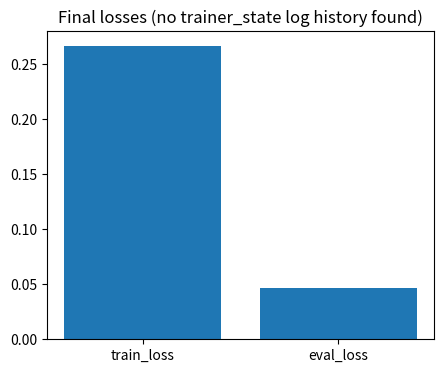

In [8]:
import json

import matplotlib.pyplot as plt

trainer_state_path = Path(result.output_dir) / 'checkpoints' / 'trainer_state.json'
trainer_state = None
if trainer_state_path.exists():
    trainer_state = json.loads(trainer_state_path.read_text(encoding='utf-8'))

if trainer_state and trainer_state.get('log_history'):
    train_points = [(entry['step'], entry['loss']) for entry in trainer_state['log_history'] if 'loss' in entry]
    eval_points = [(entry['step'], entry['eval_loss']) for entry in trainer_state['log_history'] if 'eval_loss' in entry]
    plt.figure(figsize=(8, 4))
    if train_points:
        plt.plot([step for step, _ in train_points], [loss for _, loss in train_points], label='train_loss')
    if eval_points:
        plt.plot([step for step, _ in eval_points], [loss for _, loss in eval_points], label='eval_loss')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.title('WorldSim baseline training losses')
    plt.legend()
    plt.show()
else:
    final_metrics = {
        'train_loss': summary_artifact.get('train_loss'),
        'eval_loss': summary_artifact.get('eval_loss'),
    }
    plt.figure(figsize=(5, 4))
    plt.bar(final_metrics.keys(), [value if value is not None else 0.0 for value in final_metrics.values()])
    plt.title('Final losses (no trainer_state log history found)')
    plt.show()
    final_metrics


## 9. Analyzer + Registry + Candidate Selection


In [9]:
import json

from tools.generation_analyzer import generate_report, recommend_next_action
from training.lib.qlora_smoke import (
    BEST_ADAPTER_POINTER_PATH,
    MODEL_REGISTRY_PATH,
    build_baseline_candidate_judgment,
    load_model_registry,
    register_baseline_run,
    select_best_adapter_run,
    update_best_adapter_pointer,
)

analysis_report = generate_report(sample_rows, examples_per_category=3) if sample_rows else None
analysis_report_path = Path(result.output_dir) / 'analysis_report.json'
if analysis_report is not None:
    analysis_report_path.write_text(json.dumps(analysis_report, ensure_ascii=False, indent=2), encoding='utf-8')
analysis_recommendation = recommend_next_action(analysis_report) if analysis_report else None
retry_samples = sum(1 for row in sample_rows if int(row.get('structured_attempt_count', 1) or 1) > 1)
retry_rate = round(retry_samples / len(sample_rows), 4) if sample_rows else None
registry_entry = register_baseline_run(
    MODEL_REGISTRY_PATH,
    config={**CONFIG, 'analysis_report_path': str(analysis_report_path) if analysis_report is not None else None},
    result=result,
    analysis_report=analysis_report,
    metrics={'retry_rate': retry_rate},
    created_at=run_config_artifact.get('generated_at'),
)
registry = load_model_registry(MODEL_REGISTRY_PATH)
best_run = select_best_adapter_run(registry)
best_adapter = update_best_adapter_pointer(BEST_ADAPTER_POINTER_PATH, best_run)
baseline_judgment = build_baseline_candidate_judgment(result, analysis_report)
{
    'analysis_report_path': str(analysis_report_path) if analysis_report is not None else None,
    'analysis_report': analysis_report,
    'analysis_recommendation': analysis_recommendation,
    'retry_rate': retry_rate,
    'registry_path': str(MODEL_REGISTRY_PATH),
    'registry_entry': registry_entry,
    'registered_runs': len(registry.get('runs', [])),
    'best_run': best_run,
    'best_adapter_pointer': str(BEST_ADAPTER_POINTER_PATH),
    'best_adapter': best_adapter,
    'baseline_judgment': baseline_judgment,
}


{'analysis_report_path': 'outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z/analysis_report.json',
 'analysis_report': {'total_samples': 35,
  'counts_by_failure_category': {'language_drift': 5, 'ok': 30},
  'malformed_json_count': 0,
  'truncation_count': 0,
  'fenced_json_count': 0,
  'trailing_text_count': 0,
  'prompt_leakage_count': 0,
  'enum_drift_count': 0,
  'extra_key_count': 0,
  'language_drift_count': 5,
  'semantic_low_quality_count': 0,
  'semantic_drift_count': 0,
  'json_parse_failure_rate': 0.0,
  'extra_key_rate': 0.0,
  'enum_drift_rate': 0.0,
  'retry_rate': 0.0,
  'repair_applied_rate': 0.0,
  'constrained_decoding_used_rate': 1.0,
  'structured_success_rate': 1.0,
  'affected_tasks_summary': {'G': {'language_drift': 5}},
  'extra_key_examples': [],
  'overall_status': 'semantic_quality_issue',
  'example_failures': {'language_drift': [{'task': 'G',
     'generated_assistant': '{"interpretation_ko": "The mountain beyond North Pole suggests seeking wealth i

## 9.5 Guardrail Impact Summary


In [10]:
structured_metrics = (metrics_artifact or {}).get('structured_metrics', {})
print('=' * 50)
print('GUARDRAIL IMPACT SUMMARY')
print('=' * 50)
for _k in ['structured_success_rate', 'json_parse_failure_rate', 'repair_applied_rate',
           'extra_key_rate', 'first_attempt_success', 'required_retry', 'max_retries_exhausted']:
    _v = structured_metrics.get(_k, 'N/A')
    print(f"  {_k}: {f'{_v:.4f}' if isinstance(_v, float) else _v}")
print('-' * 50)
_ssr = structured_metrics.get('structured_success_rate', 0)
if isinstance(_ssr, (int, float)) and _ssr >= 0.95:
    print('>>> PASS: Guardrails achieved 95%+ structured success <<<')
elif isinstance(_ssr, (int, float)) and _ssr >= 0.85:
    print('>>> PARTIAL: 85-95% — prompt hardening next <<<')
else:
    print('>>> INSUFFICIENT: <85% — constrained decoding needed <<<')
print('=' * 50)
{'guardrail_summary': structured_metrics}


GUARDRAIL IMPACT SUMMARY
  structured_success_rate: 1.0000
  json_parse_failure_rate: 0.0000
  repair_applied_rate: 0.0000
  extra_key_rate: 0.0000
  first_attempt_success: 35
  required_retry: 0
  max_retries_exhausted: 0
--------------------------------------------------
>>> PASS: Guardrails achieved 95%+ structured success <<<


{'guardrail_summary': {'total_attempts': 35,
  'total_successes': 35,
  'total_failures': 0,
  'json_parse_failures': 0,
  'schema_validation_failures': 0,
  'repair_applied_count': 0,
  'repairs_by_type': {},
  'keys_removed_count': 0,
  'removed_keys_frequency': {},
  'enums_normalized_count': 0,
  'first_attempt_success': 35,
  'required_retry': 0,
  'max_retries_exhausted': 0,
  'per_task': {'A': {'total': 5, 'success': 5, 'failure': 0},
   'B': {'total': 5, 'success': 5, 'failure': 0},
   'C': {'total': 5, 'success': 5, 'failure': 0},
   'G': {'total': 5, 'success': 5, 'failure': 0},
   'F': {'total': 5, 'success': 5, 'failure': 0},
   'H': {'total': 5, 'success': 5, 'failure': 0},
   'E': {'total': 5, 'success': 5, 'failure': 0}},
  'structured_success_rate': 1.0,
  'json_parse_failure_rate': 0.0,
  'repair_applied_rate': 0.0,
  'extra_key_rate': 0.0}}

## 10. Final Operational Judgment


In [11]:
BASELINE_VERDICTS = (
    'PASS_BASELINE_CANDIDATE',
    'PASS_STRUCTURAL_BUT_SEMANTIC_WEAK',
    'FAIL_BLOCKED_RUNTIME',
    'FAIL_TRAINING_INCOMPLETE',
    'FAIL_ARTIFACT_INVALID',
)
final_operational_judgment = {
    'training_completed_successfully': baseline_judgment.get('training_completed_successfully'),
    'used_true_qlora': baseline_judgment.get('used_true_qlora'),
    'adapter_exists': baseline_judgment.get('adapter_exists'),
    'losses_finite': baseline_judgment.get('losses_finite'),
    'structure_stable': baseline_judgment.get('structure_stable'),
    'semantic_quality_is_primary_remaining_issue': baseline_judgment.get('semantic_quality_is_primary_remaining_issue'),
    'is_baseline_candidate': baseline_judgment.get('is_baseline_candidate'),
    'verdict': baseline_judgment.get('verdict'),
    'output_dir': baseline_judgment.get('output_dir'),
    'adapter_dir': baseline_judgment.get('adapter_dir'),
    'train_loss': baseline_judgment.get('train_loss'),
    'eval_loss': baseline_judgment.get('eval_loss'),
    'malformed_json': analysis_report.get('malformed_json_count') if analysis_report else None,
    'fenced_json': analysis_report.get('fenced_json_count') if analysis_report else None,
    'enum_drift_total': sample_summary.get('enum_drift_total') if sample_summary else None,
    'semantic_valid': sample_summary.get('semantic_valid') if sample_summary else None,
    'semantic_low_quality': analysis_report.get('semantic_low_quality_count') if analysis_report else None,
    'semantic_drift': analysis_report.get('semantic_drift_count') if analysis_report else None,
    'language_drift': analysis_report.get('language_drift_count') if analysis_report else None,
    'analyzer_overall_status': analysis_report.get('overall_status') if analysis_report else None,
    'recommended_next_action': baseline_judgment.get('recommended_next_action'),
    'supported_verdicts': BASELINE_VERDICTS,
}
final_operational_judgment


{'training_completed_successfully': True,
 'used_true_qlora': True,
 'adapter_exists': True,
 'losses_finite': True,
 'structure_stable': True,
 'semantic_quality_is_primary_remaining_issue': True,
 'is_baseline_candidate': True,
 'verdict': 'PASS_STRUCTURAL_BUT_SEMANTIC_WEAK',
 'output_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z',
 'adapter_dir': 'outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z/adapter',
 'train_loss': 0.26650963991880416,
 'eval_loss': 0.04639367014169693,
 'malformed_json': 0,
 'fenced_json': 0,
 'enum_drift_total': 0,
 'semantic_valid': 0,
 'semantic_low_quality': 0,
 'semantic_drift': 0,
 'language_drift': 5,
 'analyzer_overall_status': 'semantic_quality_issue',
 'recommended_next_action': 'Treat this run as a structurally healthy baseline candidate, but keep semantic quality review on the shortlist before selecting it as best adapter.',
 'supported_verdicts': ('PASS_BASELINE_CANDIDATE',
  'PASS_STRUCTURAL_BUT_SEMANTIC_WEAK',
  'FAIL

## 11. Guardrail Verification Report (Auto)


In [12]:
# --- Auto-run guardrail verification report ---
from pathlib import Path as _P
import json as _json

from scripts.extract_guardrail_metrics import extract_metrics, print_report

_run_output_dir = result.output_dir if hasattr(result, 'output_dir') else str(result.to_dict().get('output_dir', ''))
_guardrail_data = extract_metrics(_run_output_dir)
print_report(_guardrail_data)

_gr_out = _P(_run_output_dir) / 'guardrail_verification_report.json'
if _P(_run_output_dir).is_dir():
    _gr_out.write_text(_json.dumps(_guardrail_data, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f"\nJSON report saved to: {_gr_out}")

_guardrail_data


GUARDRAIL VERIFICATION REPORT
Output: /home/hyunlord/github/worldsim-training/outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z

--- Structured Metrics (from BatchMetrics) ---
  structured_success_rate: 1.0000
  json_parse_failure_rate: 0.0000
  repair_applied_rate: 0.0000
  extra_key_rate: 0.0000
  total_attempts: 35
  total_successes: 35
  total_failures: 0
  first_attempt_success: 35
  required_retry: 0
  max_retries_exhausted: 0

--- Per-Task Breakdown ---
  Task A: 5/5 (100.00%)
  Task B: 5/5 (100.00%)
  Task C: 5/5 (100.00%)
  Task E: 5/5 (100.00%)
  Task F: 5/5 (100.00%)
  Task G: 5/5 (100.00%)
  Task H: 5/5 (100.00%)

--- Repairs Applied ---
  (none)

--- Top Removed Keys (Schema Leakage) ---
  (none)

--- Analysis Report Summary ---
  overall_status: semantic_quality_issue
  structured_success_rate: 1.0
  malformed_json_count: 0
  fenced_json_count: 0
  enum_drift_total: None
  extra_keys_count: 0
  semantic_low_quality_count: 0

--- Decision ---
  VERDICT: PASS — guar

{'output_dir': '/home/hyunlord/github/worldsim-training/outputs/baseline/worldsim-v31-mix-v1/run-20260313T020326Z',
 'structured_metrics': {'total_attempts': 35,
  'total_successes': 35,
  'total_failures': 0,
  'json_parse_failures': 0,
  'schema_validation_failures': 0,
  'repair_applied_count': 0,
  'repairs_by_type': {},
  'keys_removed_count': 0,
  'removed_keys_frequency': {},
  'enums_normalized_count': 0,
  'first_attempt_success': 35,
  'required_retry': 0,
  'max_retries_exhausted': 0,
  'per_task': {'A': {'total': 5, 'success': 5, 'failure': 0},
   'B': {'total': 5, 'success': 5, 'failure': 0},
   'C': {'total': 5, 'success': 5, 'failure': 0},
   'G': {'total': 5, 'success': 5, 'failure': 0},
   'F': {'total': 5, 'success': 5, 'failure': 0},
   'H': {'total': 5, 'success': 5, 'failure': 0},
   'E': {'total': 5, 'success': 5, 'failure': 0}},
  'structured_success_rate': 1.0,
  'json_parse_failure_rate': 0.0,
  'repair_applied_rate': 0.0,
  'extra_key_rate': 0.0},
 'analysis_r